In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

from data_pipeline import create_dataset_pipeline


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 50

# TRAIN_DIR = '/content/dataset/train'
# VAL_DIR = '/content/dataset/valid'
# TEST_DIR = '/content/dataset/test'

TRAIN_DIR = '/dataset/train'
VAL_DIR = '/dataset/valid'
TEST_DIR = '/dataset/test'


In [5]:
train_ds = create_dataset_pipeline(TRAIN_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, augment=True, rescale=False)
val_ds = create_dataset_pipeline(VAL_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False, augment=False, rescale=False)
test_ds = create_dataset_pipeline(TEST_DIR, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False, augment=False, rescale=False)

class_names = sorted(os.listdir(TEST_DIR))


Found 8739 files belonging to 50 classes.
Found 250 files belonging to 50 classes.
Found 250 files belonging to 50 classes.


In [6]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

print(f'Base model layers: {len(base_model.layers)}')
print(f'Base model params: {base_model.count_params():,}')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model layers: 154
Base model params: 2,257,984


In [ ]:
def build_transfer_model(base):
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    # Pipeline delivers raw [0, 255] pixels; preprocess_input maps them to [-1, 1].
    x = preprocess_input(inputs)
    # training=False keeps BN layers in inference mode so their running stats stay frozen.
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

tl_model = build_transfer_model(base_model)
tl_model.summary()


In [8]:
tl_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_HEAD = 10

history_head = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD
)


Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 429ms/step - accuracy: 0.6289 - loss: 1.4361 - val_accuracy: 0.8400 - val_loss: 0.6141
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 100s 332ms/step - accuracy: 0.8353 - loss: 0.5749 - val_accuracy: 0.8680 - val_loss: 0.4812
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 141s 329ms/step - accuracy: 0.8670 - loss: 0.4437 - val_accuracy: 0.8960 - val_loss: 0.4162
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 91s 329ms/step - accuracy: 0.8866 - loss: 0.3734 - val_accuracy: 0.8720 - val_loss: 0.4333
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 91s 329ms/step - accuracy: 0.9003 - loss: 0.3283 - val_accuracy: 0.8920 - val_loss: 0.4222
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 90s 325ms/step - accuracy: 0.9066 - loss: 0.3069 - val_accuracy: 0.8800 - val_loss: 0.3983
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 90s 328ms/step - accuracy: 0.9177 - loss: 0.2727 - val_accuracy: 0.8960 - val_loss: 0.4057
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 92s 333ms/step - accuracy: 0.9238 - loss

In [ ]:
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_params = sum([tf.size(w).numpy() for w in tl_model.trainable_weights])
print(f'Fine-tuning from layer index {FINE_TUNE_AT} / {len(base_model.layers)}')
print(f'Trainable params after unfreeze: {trainable_params:,}')

tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Fine-tuning from layer index 124 / 154
Trainable params after unfreeze: 1,574,770


In [10]:
EPOCHS_FINETUNE = 10
TOTAL_EPOCHS = EPOCHS_HEAD + EPOCHS_FINETUNE

# initial_epoch continues the epoch counter from phase 1 so both histories
# concatenate cleanly for the combined plot below.
history_ft = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_head.epoch[-1] + 1
)


Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 136s 441ms/step - accuracy: 0.9382 - loss: 0.1888 - val_accuracy: 0.8920 - val_loss: 0.4013
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 117s 381ms/step - accuracy: 0.9451 - loss: 0.1627 - val_accuracy: 0.9000 - val_loss: 0.3892
Epoch 13/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 142s 381ms/step - accuracy: 0.9488 - loss: 0.1505 - val_accuracy: 0.8920 - val_loss: 0.3557
Epoch 14/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 102s 372ms/step - accuracy: 0.9577 - loss: 0.1373 - val_accuracy: 0.9000 - val_loss: 0.3639
Epoch 15/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 102s 372ms/step - accuracy: 0.9561 - loss: 0.1397 - val_accuracy: 0.9040 - val_loss: 0.3422
Epoch 16/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 100s 362ms/step - accuracy: 0.9566 - loss: 0.1300 - val_accuracy: 0.9000 - val_loss: 0.3537
Epoch 17/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 97s 354ms/step - accuracy: 0.9610 - loss: 0.1232 - val_accuracy: 0.9080 - val_loss: 0.3406
Epoch 18/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 96s 350ms/step - accuracy: 0.

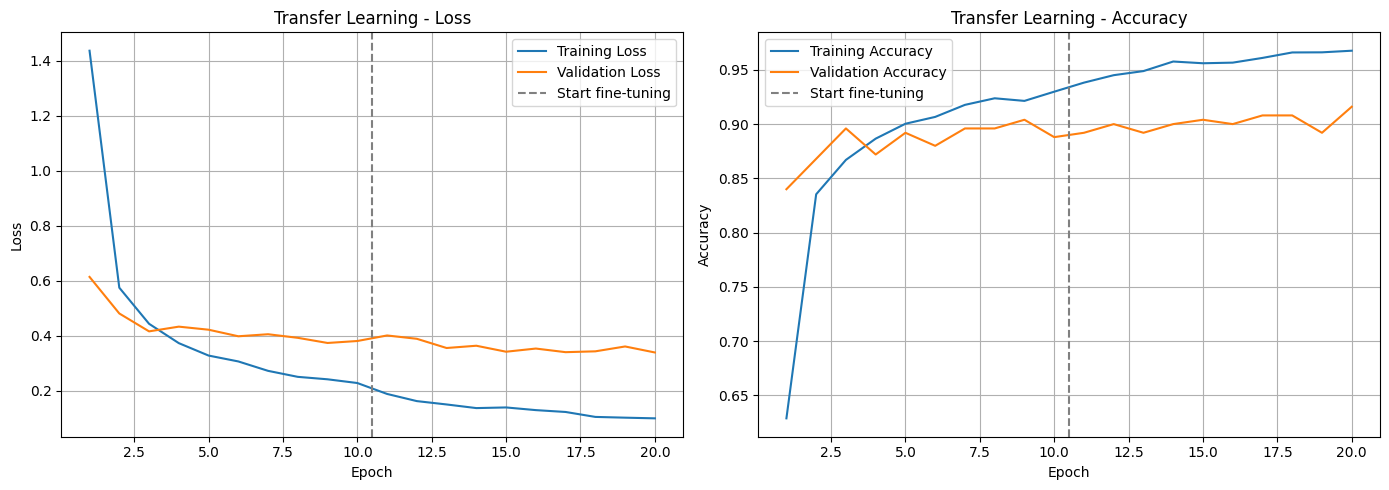

In [11]:
loss = history_head.history['loss'] + history_ft.history['loss']
val_loss = history_head.history['val_loss'] + history_ft.history['val_loss']
acc = history_head.history['accuracy'] + history_ft.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_ft.history['val_accuracy']

epochs_range = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, loss, label='Training Loss')
axes[0].plot(epochs_range, val_loss, label='Validation Loss')
axes[0].axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', label='Start fine-tuning')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Transfer Learning - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, acc, label='Training Accuracy')
axes[1].plot(epochs_range, val_acc, label='Validation Accuracy')
axes[1].axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', label='Start fine-tuning')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Transfer Learning - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [12]:
test_loss, test_acc = tl_model.evaluate(test_ds, verbose=0)
print(f'Transfer Learning (MobileNetV2) - test accuracy: {test_acc:.4f} | test loss: {test_loss:.4f}')


Transfer Learning (MobileNetV2) - test accuracy: 0.9600 | test loss: 0.1594


In [13]:
y_true, y_pred = [], []
for x_batch, y_batch in test_ds:
    preds = tl_model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))


                      precision    recall  f1-score   support

      AIR COMPRESSOR      1.000     1.000     1.000         5
          ALTERNATOR      1.000     1.000     1.000         5
             BATTERY      0.833     1.000     0.909         5
       BRAKE CALIPER      1.000     0.800     0.889         5
           BRAKE PAD      1.000     1.000     1.000         5
         BRAKE ROTOR      1.000     1.000     1.000         5
            CAMSHAFT      1.000     0.600     0.750         5
          CARBERATOR      1.000     1.000     1.000         5
        CLUTCH PLATE      1.000     1.000     1.000         5
         COIL SPRING      1.000     1.000     1.000         5
          CRANKSHAFT      1.000     1.000     1.000         5
       CYLINDER HEAD      1.000     0.600     0.750         5
         DISTRIBUTOR      1.000     1.000     1.000         5
        ENGINE BLOCK      0.714     1.000     0.833         5
        ENGINE VALVE      1.000     1.000     1.000         5
       

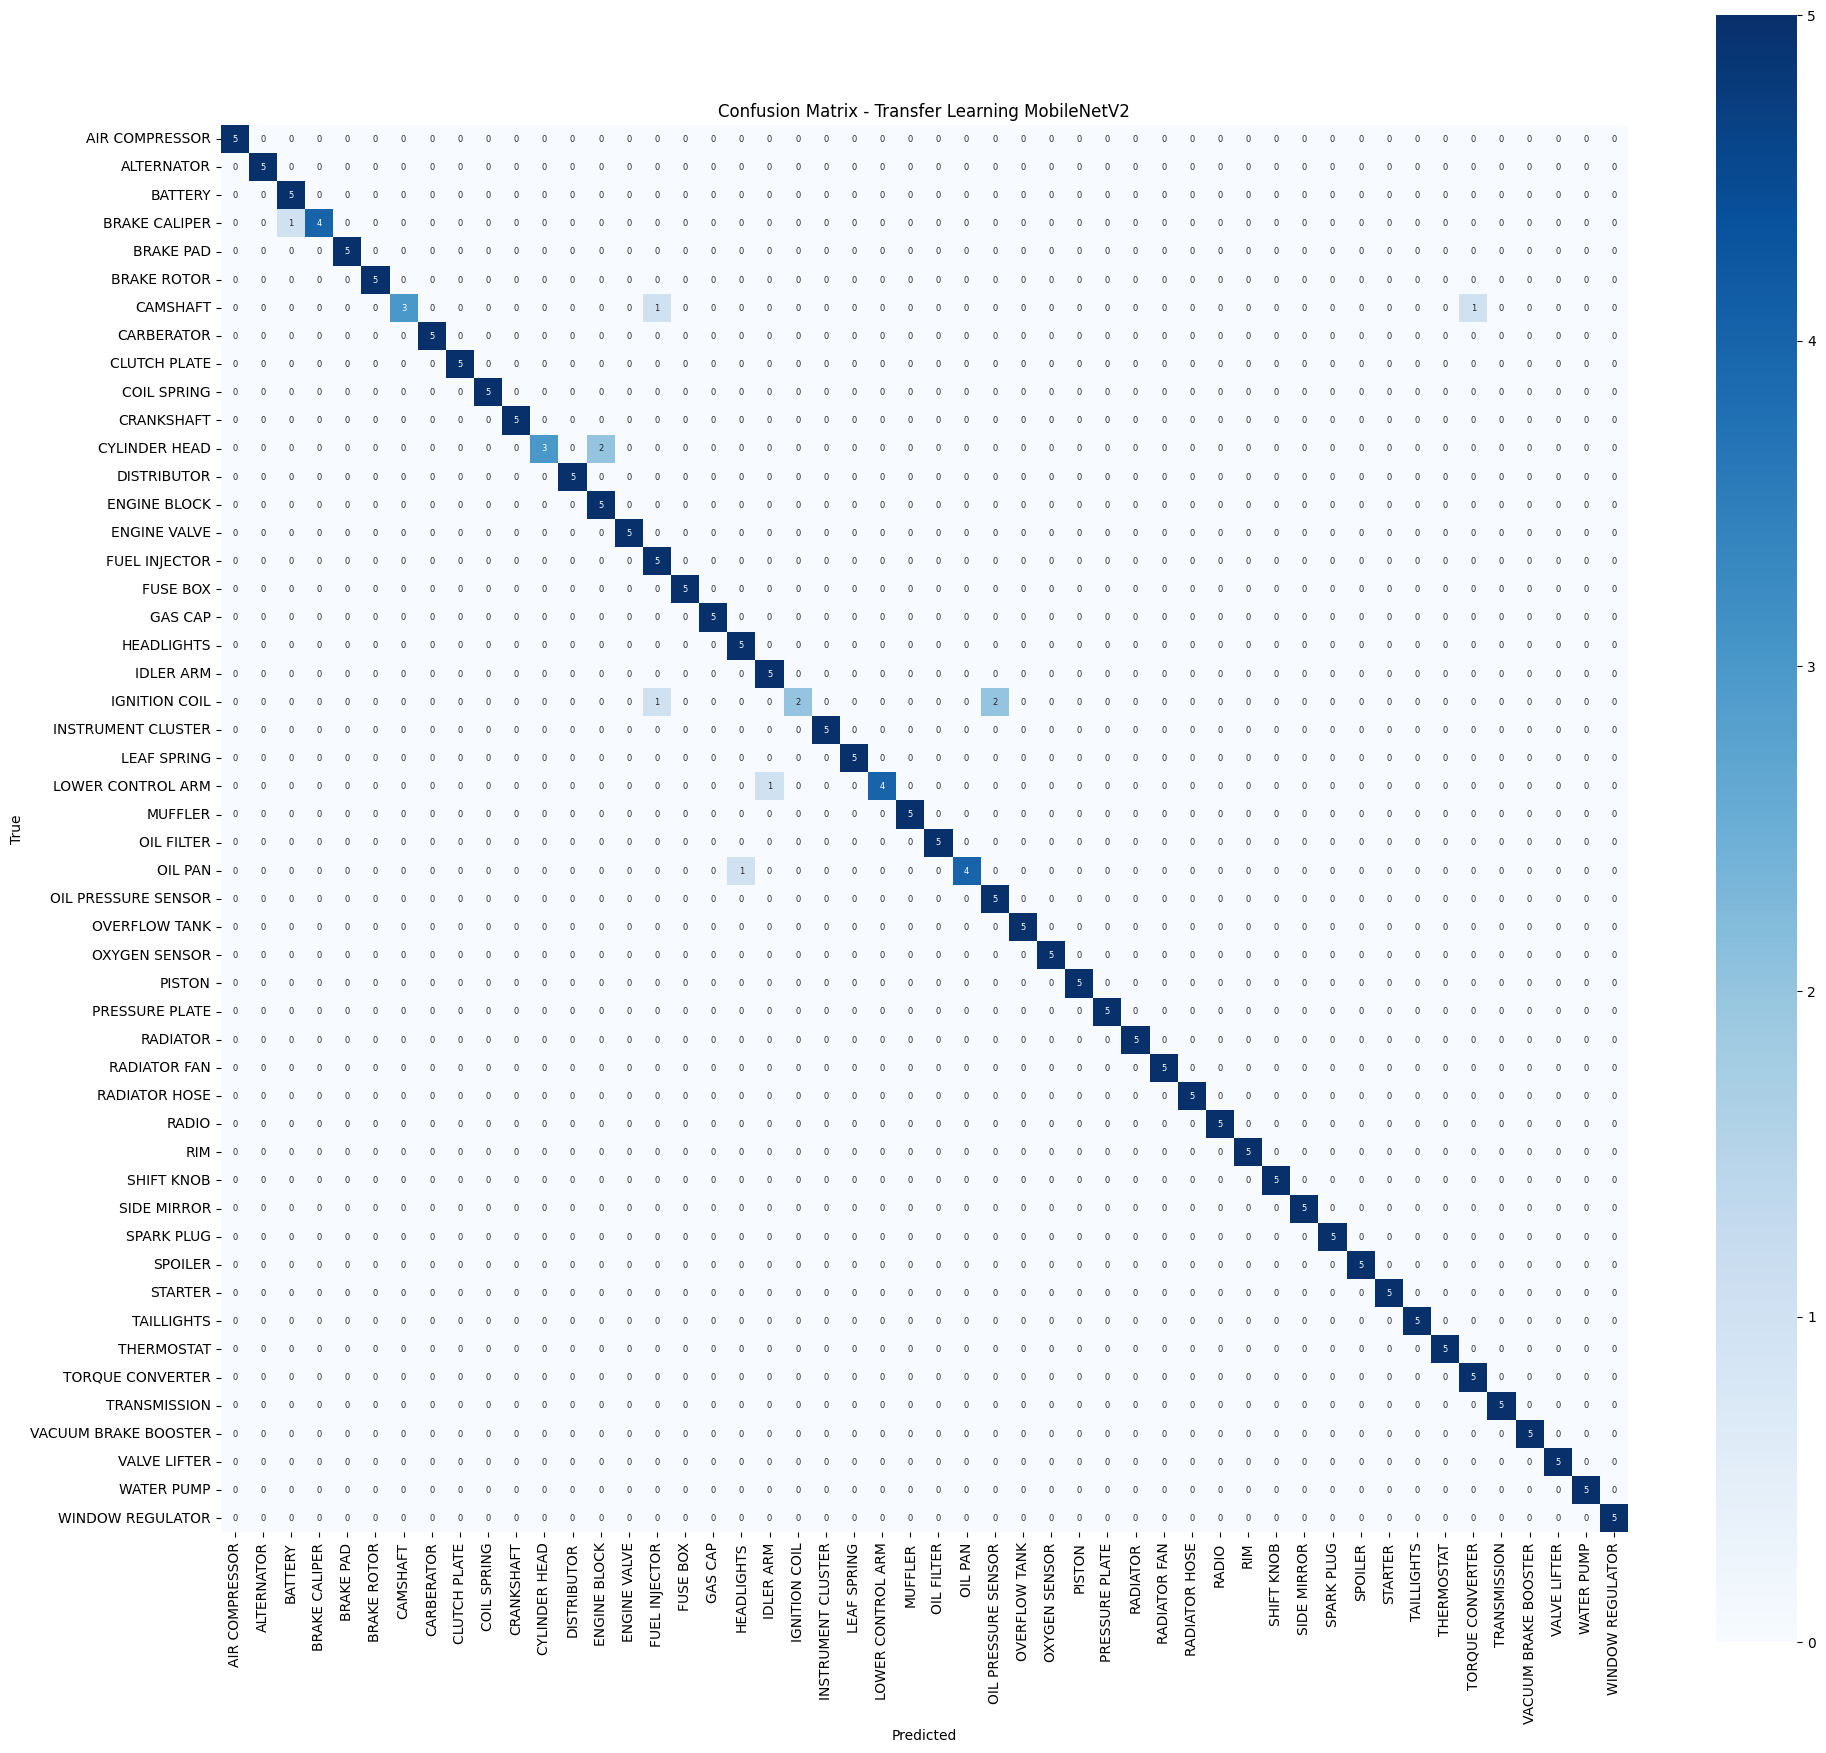

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    cbar=True,
    square=True,
    annot=True,
    fmt='d',
    annot_kws={'size': 6}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Transfer Learning MobileNetV2')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [15]:
# Zero out the diagonal so we only rank the misclassifications.
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_confusions = np.dstack(
    np.unravel_index(
        np.argsort(cm_no_diag.ravel())[::-1][:3],
        cm.shape
    )
)[0]

for i, (true_idx, pred_idx) in enumerate(top_confusions, 1):
    count = cm_no_diag[true_idx, pred_idx]
    print(f"{i}. True: {class_names[true_idx]} → Predicted: {class_names[pred_idx]} ({count} cases)")


1. True: IGNITION COIL → Predicted: OIL PRESSURE SENSOR (2 cases)
2. True: CYLINDER HEAD → Predicted: ENGINE BLOCK (2 cases)
3. True: LOWER CONTROL ARM → Predicted: IDLER ARM (1 cases)


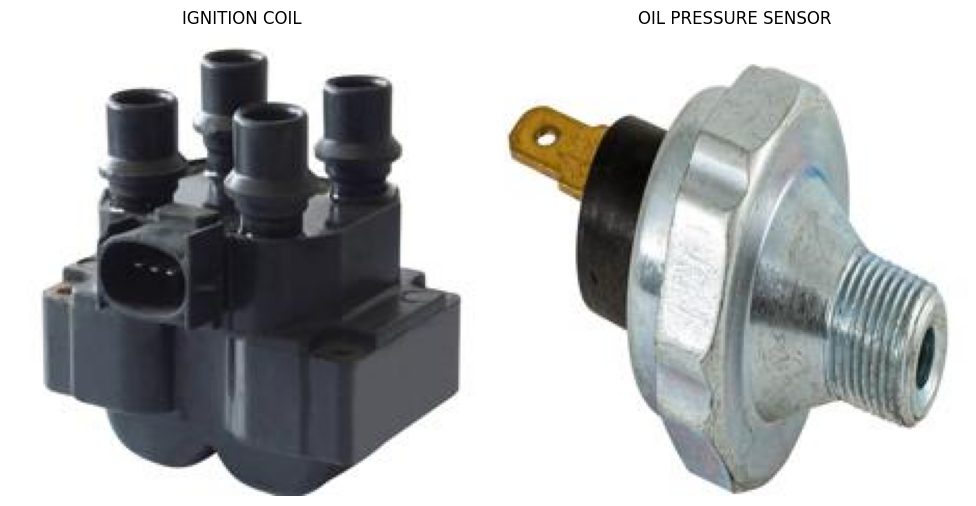

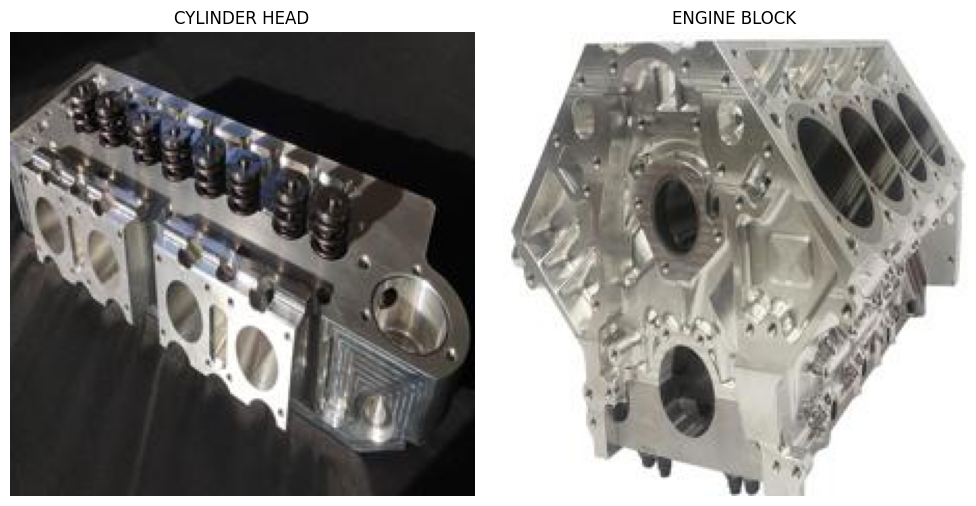

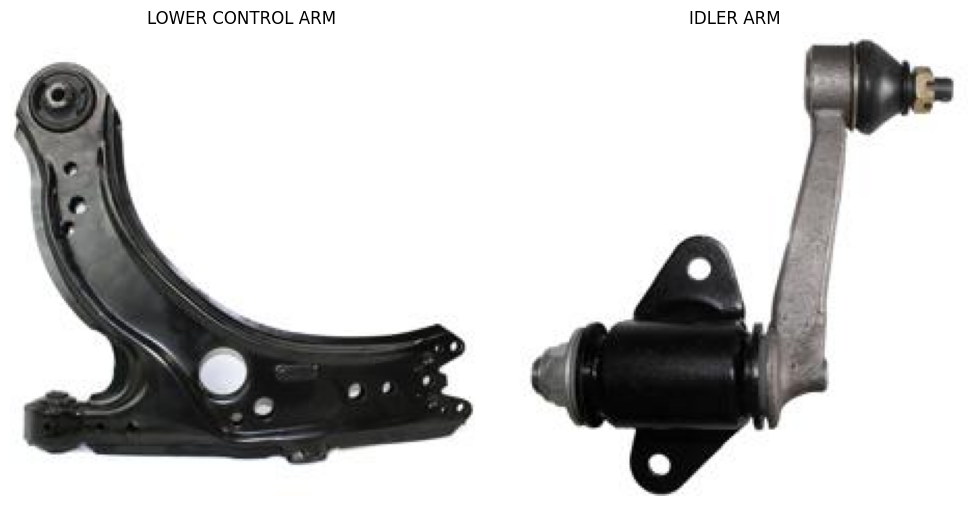

In [16]:
from PIL import Image

def show_pair(class_a, class_b, base_dir=TEST_DIR):
    img_a = os.listdir(os.path.join(base_dir, class_a))[0]
    img_b = os.listdir(os.path.join(base_dir, class_b))[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(Image.open(os.path.join(base_dir, class_a, img_a)))
    axes[0].set_title(class_a)
    axes[0].axis('off')
    axes[1].imshow(Image.open(os.path.join(base_dir, class_b, img_b)))
    axes[1].set_title(class_b)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

pairs = [(class_names[true_idx], class_names[pred_idx]) for true_idx, pred_idx in top_confusions]

for a, b in pairs:
    show_pair(a, b)


## Results comparison

| Model | Val acc | Test acc |
|---|---|---|
| Custom CNN (M3.3) | 0.49 | 0.480 |
| Custom CNN + Augmentation (M3.5) | 0.68 | — |
| Custom CNN + Aug + Dropout (M3.5) | 0.56 | 0.536 |
| **Transfer Learning MobileNetV2 (M3.6)** | **0.92** | **0.956** |

The baseline CNN concentrates ~22M parameters in the Dense layer after Flatten. With only ~175 images per class, model capacity vastly exceeds the data volume, so the network memorizes the training set (train acc ~0.99) while validation stagnates around 0.49.

Augmentation alone forces the model to learn features invariant to small geometric transformations. Overfitting weakens substantially and validation accuracy jumps to ~0.68 — the largest per-epoch gain of the series, since augmentation does not slow learning the way dropout does. This variant was not evaluated on the test set.

Adding dropout on top strengthens regularization but slows convergence. Within the same 20-epoch budget the model reaches only ~0.54 test accuracy with the curves still rising; the generalization potential is better than aug-only, but more epochs would be needed to demonstrate it.

Transfer learning bypasses the underlying problem: MobileNetV2 reuses features learned on 1.3M ImageNet images instead of learning them from 8.7k. A two-phase schedule (head-only at LR=1e-3, then top-30 layers at LR=1e-5) reaches 0.956 test accuracy with ~10x fewer parameters, no overfitting, and classes that had f1=0 in the baseline (LEAF SPRING, OIL PAN, WATER PUMP) now score f1 >= 0.889.

Regularization techniques target the symptom (overfitting), while transfer learning addresses the root cause (too little data for too many features to learn from scratch). On small, specialized datasets, reusing pretrained features is far more effective than any adjustment to a model trained from scratch.
